In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import glob
import os

In [2]:
csv_files = glob.glob("*.csv")

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
car data.csv
CAR DETAILS FROM CAR DEKHO.csv
Car details v3.csv
car details v4.csv


In [3]:
file_path = csv_files[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("File:", file_path)

Dataset loaded successfully!
File: car data.csv


In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (301, 9)

Column names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Data types:
Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.head()

,car_name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [10]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].str.strip().str.lower()

print("Categorical values standardized successfully.")

Categorical values standardized successfully.


C:\Users\krish\AppData\Local\Temp\ipykernel_20072\2545091247.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [14]:
df["brand"] = df["car_name"].str.split().str[0]

df[["car_name", "brand"]].head()

,car_name,brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


In [15]:
df["year"] = pd.to_numeric(df["year"], errors="coerce")

df["car_age"] = pd.Timestamp.now().year - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [16]:
df["selling_price"] = pd.to_numeric(df["selling_price"], errors="coerce")
df["present_price"] = pd.to_numeric(df["present_price"], errors="coerce")
df["kms_driven"] = pd.to_numeric(df["kms_driven"], errors="coerce")

df.dtypes

car_name             str
year               int64
selling_price    float64
present_price    float64
kms_driven         int64
fuel_type            str
seller_type          str
transmission         str
owner              int64
brand             object
car_age            int64
dtype: object

In [17]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
car_name         0
year             0
selling_price    0
present_price    0
kms_driven       0
fuel_type        0
seller_type      0
transmission     0
owner            0
brand            0
car_age          0
dtype: int64


In [18]:
df = df.dropna(subset=["selling_price"]).reset_index(drop=True)

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
car_name         0
year             0
selling_price    0
present_price    0
kms_driven       0
fuel_type        0
seller_type      0
transmission     0
owner            0
brand            0
car_age          0
dtype: int64


C:\Users\krish\AppData\Local\Temp\ipykernel_20072\3973414228.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [19]:
df = df[df["car_age"] >= 0].reset_index(drop=True)

print("Final dataset shape after cleaning:", df.shape)

Final dataset shape after cleaning: (299, 11)


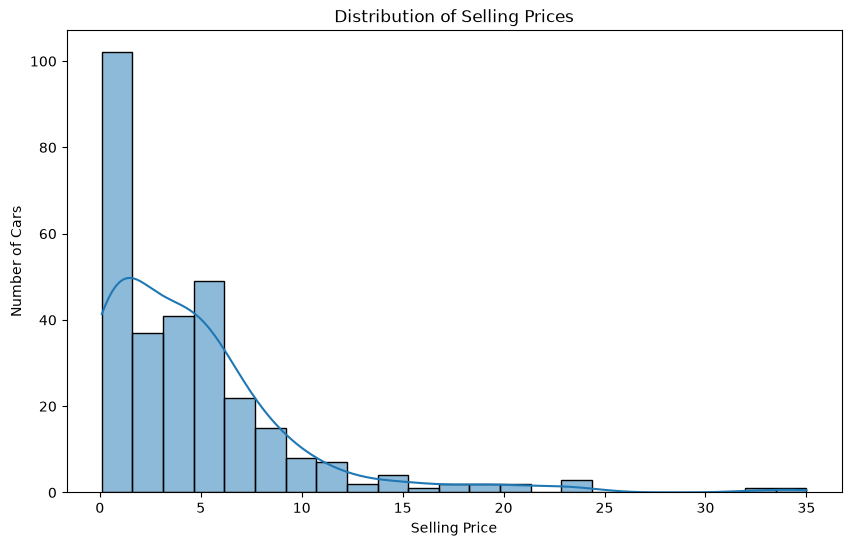

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(df["selling_price"], kde=True)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

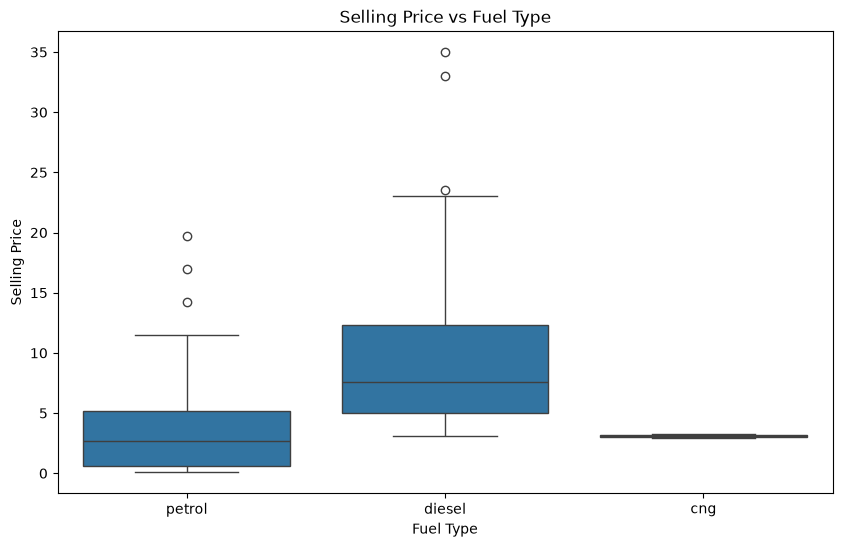

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="fuel_type", y="selling_price")

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

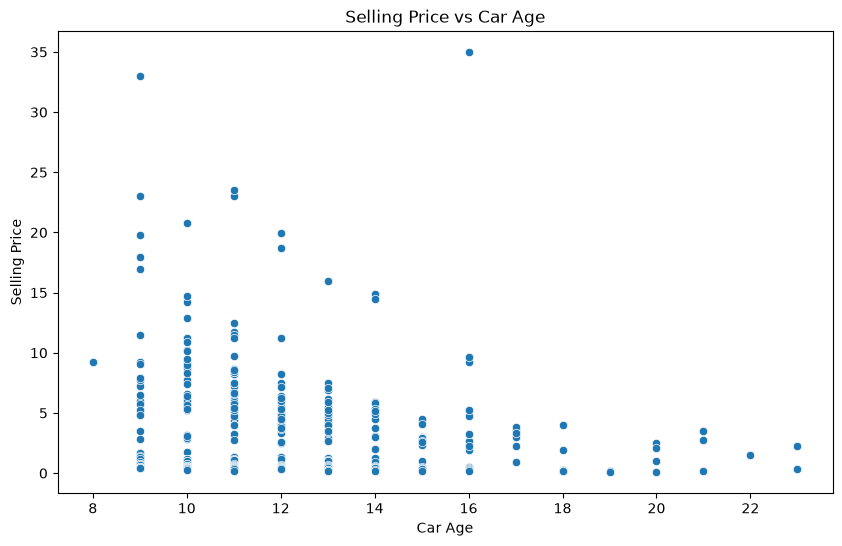

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="car_age", y="selling_price")

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

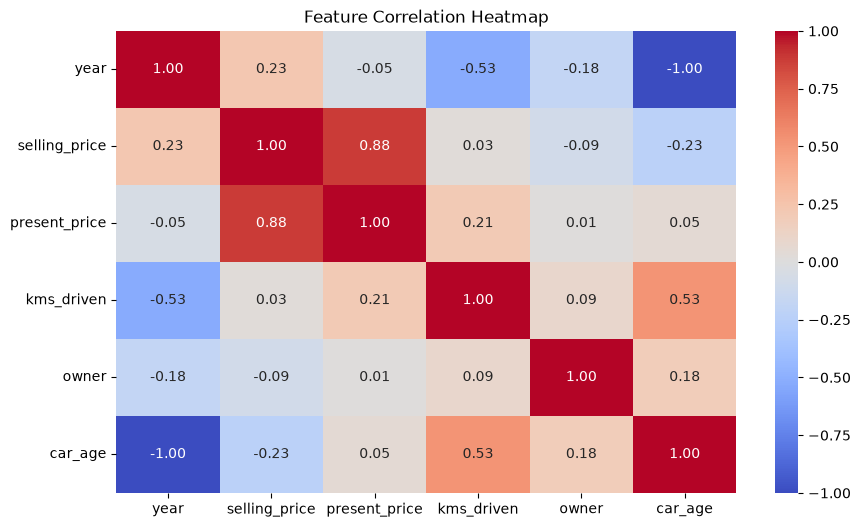

In [23]:
plt.figure(figsize=(10, 6))

correlation_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [24]:
print("Columns in the cleaned dataset:")
print(df.columns.tolist())

Columns in the cleaned dataset:
['car_name', 'year', 'selling_price', 'present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner', 'brand', 'car_age']


In [25]:
columns_to_drop = [
    "selling_price",
    "car_name",
    "year"
]

X = df.drop(columns=columns_to_drop)
y = df["selling_price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['present_price', 'kms_driven', 'fuel_type', 'seller_type', 'transmission', 'owner', 'brand', 'car_age']

Target:
selling_price


In [26]:
categorical_features = X.select_dtypes(include="object").columns

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

print("Shape after encoding:", X_encoded.shape)

X_encoded.head()

Shape after encoding: (299, 51)


C:\Users\krish\AppData\Local\Temp\ipykernel_20072\1110644492.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


,present_price,kms_driven,owner,car_age,fuel_type_diesel,fuel_type_petrol,seller_type_individual,transmission_manual,brand_activa,brand_alto,...,brand_suzuki,brand_swift,brand_sx4,brand_tvs,brand_um,brand_verna,brand_vitara,brand_wagon,brand_xcent,brand_yamaha
0,5.59,27000,0,12,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,9.54,43000,0,13,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,9.85,6900,0,9,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4.15,5200,0,15,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,6.87,42450,0,12,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False


In [27]:
X_encoded = X_encoded.astype(float)

print("Final feature data types:")
print(X_encoded.dtypes)

Final feature data types:
present_price             float64
kms_driven                float64
owner                     float64
car_age                   float64
fuel_type_diesel          float64
fuel_type_petrol          float64
seller_type_individual    float64
transmission_manual       float64
brand_activa              float64
brand_alto                float64
brand_amaze               float64
brand_bajaj               float64
brand_baleno              float64
brand_brio                float64
brand_camry               float64
brand_ciaz                float64
brand_city                float64
brand_corolla             float64
brand_creta               float64
brand_dzire               float64
brand_elantra             float64
brand_eon                 float64
brand_ertiga              float64
brand_etios               float64
brand_fortuner            float64
brand_grand               float64
brand_hero                float64
brand_honda               float64
brand_hyosung         

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (239, 51)
Testing data shape: (60, 51)


In [29]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [30]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Regressor trained successfully.")

Random Forest Regressor trained successfully.


In [31]:
def evaluate_model(model_name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    }

In [32]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

random_forest_results = evaluate_model(
    "Random Forest Regressor",
    y_test,
    random_forest_predictions
)

results = pd.DataFrame([
    linear_results,
    random_forest_results
])

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.383500,2.569901,0.743750
1,Random Forest Regressor,1.368577,3.275082,0.583826


In [33]:
best_model_name = results.loc[
    results["RMSE"].idxmin(),
    "Model"
]

print("Best-performing model:", best_model_name)

Best-performing model: Linear Regression


In [34]:
if best_model_name == "Random Forest Regressor":
    best_model = random_forest_model
    best_predictions = random_forest_predictions
else:
    best_model = linear_model
    best_predictions = linear_predictions

print("Best model selected:", best_model_name)

Best model selected: Linear Regression


In [35]:
if best_model_name == "Random Forest Regressor":
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X_encoded.columns
    ).sort_values(ascending=False)
else:
    feature_importance = pd.Series(
        np.abs(best_model.coef_),
        index=X_encoded.columns
    ).sort_values(ascending=False)

feature_importance.head(10)

brand_activa      3.965322
brand_innova      3.924393
brand_creta       3.746914
brand_land        2.784716
brand_elantra     2.491403
brand_um          2.431236
brand_fortuner    2.188358
brand_ktm         2.108459
brand_yamaha      2.010809
brand_honda       2.002408
dtype: float64

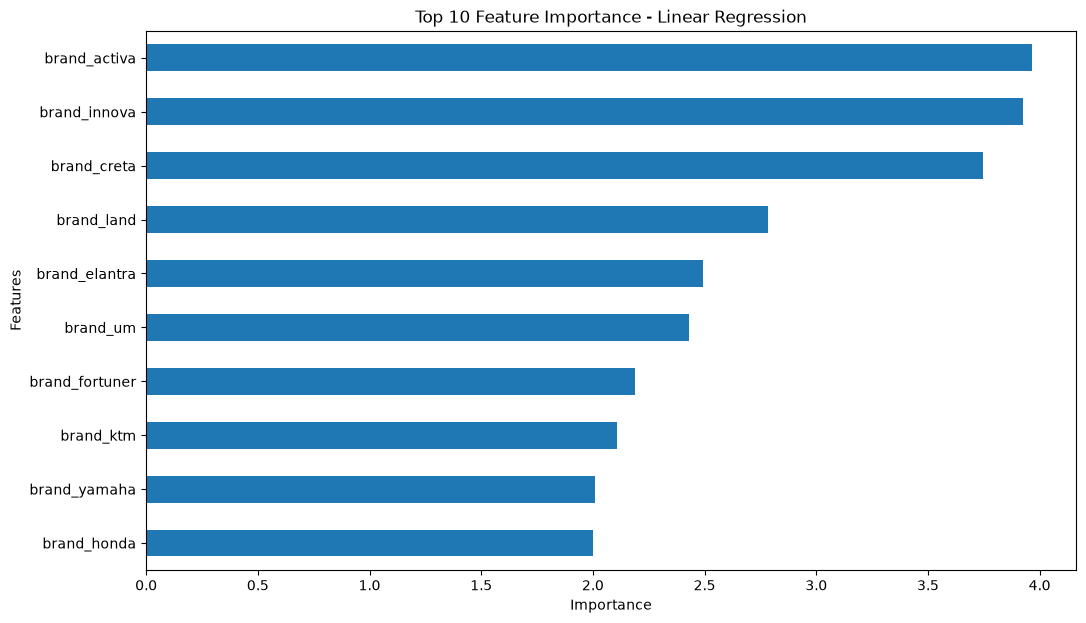

In [36]:
plt.figure(figsize=(12, 7))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title(f"Top 10 Feature Importance - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [37]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": best_predictions
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,8.441661
1,8.35,8.177500
2,0.45,1.998106
3,7.45,6.849713
4,5.25,9.855900
5,5.25,4.779723
6,5.85,7.944314
7,1.15,1.973706
8,9.25,8.215622
9,0.38,-0.928453


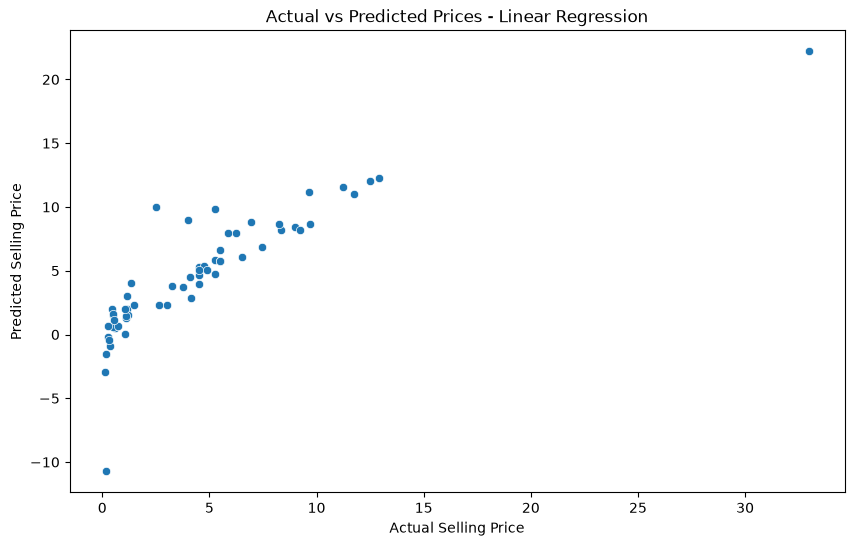

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=best_predictions
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Actual vs Predicted Prices - {best_model_name}")

plt.show()

In [39]:
print("FINAL MODEL PERFORMANCE")
print("=" * 40)

best_row = results[results["Model"] == best_model_name].iloc[0]

print("Model:", best_model_name)
print("MAE :", round(best_row["MAE"], 2))
print("RMSE:", round(best_row["RMSE"], 2))
print("R²  :", round(best_row["R² Score"], 4))

FINAL MODEL PERFORMANCE
Model: Linear Regression
MAE : 1.38
RMSE: 2.57
R²  : 0.7438


In [40]:
print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
brand_activa      3.965322
brand_innova      3.924393
brand_creta       3.746914
brand_land        2.784716
brand_elantra     2.491403
brand_um          2.431236
brand_fortuner    2.188358
brand_ktm         2.108459
brand_yamaha      2.010809
brand_honda       2.002408
dtype: float64


In [41]:
print("CONCLUSION")
print("=" * 40)

print(f"The best-performing model is {best_model_name}.")
print(
    f"It achieved an R² score of {best_row['R² Score']:.4f}, "
    f"with an RMSE of {best_row['RMSE']:.2f} "
    f"and an MAE of {best_row['MAE']:.2f}."
)
print("The feature-importance analysis shows which car characteristics have the strongest influence on predicted selling price.")

CONCLUSION
The best-performing model is Linear Regression.
It achieved an R² score of 0.7438, with an RMSE of 2.57 and an MAE of 1.38.
The feature-importance analysis shows which car characteristics have the strongest influence on predicted selling price.
